# Machine Learning for Single-Cell Biology
***

Winter Semester 2024/25<br />
Manfred Claassen, Matthias Bruhns, Jan Schleicher
<br />
***

## Assignment 4

As discussed in the lecture, single-cell data with spatial resolution can be used to detect and define cellular niches. Use the provided dataset `data.parquet` from the paper below for the analysis. The columns "X" and "Y" contain the physical coordinates, "sample" represents the sample origin.

Christian M. Schürch et al. Coordinated Cellular Neighborhoods Orchestrate Antitumoral Immunity at the Colorectal Cancer Invasive Front, Cell, Volume 182, Issue 5, 2020 https://doi.org/10.1016/j.cell.2020.07.005.

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import MiniBatchKMeans
from scipy.stats import median_abs_deviation

from skbio.stats.composition import ilr, multiplicative_replacement
from sklearn.metrics.cluster import adjusted_rand_score

import matplotlib.pyplot as plt
import seaborn as sns

from typing import List, Tuple

sns.set_style("ticks")
%matplotlib inline

### Coding hints

As always, there are several ways to implement the tasks. If you are interested in writing very efficient and concise code you might want to look at Pandas functions. We especially want to highlight:

- groupby
- melt
- crosstab

In [2]:
DATA_PATH = "data/"

In [3]:
# Load the data
data = pd.read_parquet(os.path.join(DATA_PATH, "data.parquet"))
CELLTYPES = data["Celltype"].unique().tolist()

### Task 1: KNN-based neighborhood analysis (60 points)

Redo the neighborhood analysis described in the original publication. Follow these steps:

A. Construct neighborhoods using a KNN-graph with k = 10 for each cell. (15 points)

B. For each cell in each neighborhood, calculate the distribution of cell types (column "Celltype"). (25 points)

C. Using these features, cluster the cells using MiniBatchKMeans into 10 clusters. (15 points)

D. For each cluster, calculate the enrichment score with the given `enrichment_score` function and visualize the result in a suitable manner. (5 points)


In [4]:
def task1a_get_k_nearest_neighbors(sample_data: pd.DataFrame, n_neighbors: int) -> np.ndarray:
    """
    Find the k-nearest neighbors for each cell in the sample
    :param sample_data: A DataFrame of length n_cells_sample with columns X and Y
    :param n_neighbors: The number of neighbors
    :return: A numpy array with neighbor indices of shape (n_cells_sample, n_neighbors)
    """
    knn = NearestNeighbors(
        n_neighbors = n_neighbors,
        n_jobs = 4,
        # Euclidean distance
        metric = "minkowski", p = 2
    )

    knn_fit = knn.fit(sample_data[["X", "Y"]])
    is_neighbor = knn_fit.kneighbors_graph(sample_data[["X", "Y"]])

    neighbors = np.array([list(is_neighbor[row].nonzero()[1]) for row in range(is_neighbor.shape[0])])
    
    return neighbors

In [5]:
def task1b_get_neighborhood_composition(sample_data: pd.DataFrame, neighbors: np.ndarray) -> pd.DataFrame:
    """
    Calculate the composition of each cell's k-nearest neighbors w.r.t. cell types
    :param sample_data: A DataFrame of length n_cells_sample with columns X, Y, and Celltype
    :param neighbors: A numpy array with neighbor indices of shape (n_cells_sample, n_neighbors)
    :return: A DataFrame of shape (n_cells_sample, n_celltypes) containing neighborhood cell type frequencies.
    """
    neighbors_flattened = neighbors.flatten()

    ids = np.repeat(data.CellID, neighbors.shape[1])
    neighbor_celltype = pd.DataFrame({ "From": ids, "To": neighbors_flattened })

    neighbor_celltype = neighbor_celltype.merge(data[["CellID", "Celltype"]], left_on = "To", right_on = "CellID")

    cell_type_frequencies_sample = neighbor_celltype.groupby(["From", "Celltype"]).size().unstack(fill_value = 0)
    cell_type_frequencies_sample = cell_type_frequencies_sample.div(
        cell_type_frequencies_sample.sum(axis = 1),
        axis = 0
    )

    return cell_type_frequencies_sample

In [6]:
# Compute cell neighborhoods for the samples and celltype frequencies

# Make sure that cell ID matches the index
assert np.all([ i in data.CellID for i in range(len(data)) ])

n_neighbors = 10
neighbors = task1a_get_k_nearest_neighbors(data, n_neighbors = n_neighbors)
cell_type_frequencies = task1b_get_neighborhood_composition(data, neighbors)

In [7]:
def task1c_clustering(cell_type_frequencies: pd.DataFrame, n_clusters: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Cluster cells based on their neighborhood compositions
    :param cell_type_frequencies: A DataFrame of shape (n_cells, n_celltypes) containing neighborhood cell type frequencies.
    :param n_clusters: Number of clusters for K-Means clustering
    :return: Numpy array with cluster label for each cell of shape (n_cells,);
    numpy array with mean composition of shape (n_clusters, n_celltypes)
    """
    kmeans = MiniBatchKMeans(
        n_clusters = n_clusters,
        random_state = 132 # 11 * 12
    )

    kmeans_fit = kmeans.fit(cell_type_frequencies)

    clusters = kmeans_fit.predict(cell_type_frequencies)
    mean_values = kmeans.cluster_centers_
    
    return clusters, mean_values

In [40]:
# Cluster cells based on their neighborhood compositions
clusters1, mean_values1 = task1c_clustering(cell_type_frequencies, n_clusters = n_neighbors)

In [9]:
def enrichment_score(cluster_mean_values: np.ndarray, all_values: np.ndarray) -> np.ndarray:
    """
    Calculate cell type enrichment scores for each cluster
    :param cluster_mean_values: Numpy array with mean composition of shape (n_clusters, n_celltypes)
    :param all_values: Numpy array with neighborhood compositions for all cells of shape (n_cells, n_celltypes)
    :return: Numpy array with enrichment scores of shape (n_clusters, n_celltypes)
    """
    assert cluster_mean_values.shape == (10, 29)
    assert all_values.shape == (258385, 29)
    return np.log2(((cluster_mean_values + all_values.mean(axis = 0)) /
                    (cluster_mean_values + all_values.mean(axis = 0)).sum(axis = 1, keepdims = True)) / all_values.mean(
        axis = 0))

In [51]:
def task1d_plot_enrichment_scores(enrichment_scores: np.ndarray) -> None:
    """
    Plot the cell type enrichment scores for all clusters.
    :param enrichment_scores: Numpy array with enrichment scores of shape (n_clusters, n_celltypes)
    :return:
    """
    abs_max = np.abs(enrichment_scores)
    vmin, vmax = -np.max(abs_max), np.max(abs_max)

    plt.imshow(enrichment_scores, cmap = "bwr", vmin = vmin, vmax = vmax)
    plt.ylabel("Cluster")
    plt.xlabel("Cell type")
    plt.colorbar(fraction = 0.016, pad = 0.04)

    return None

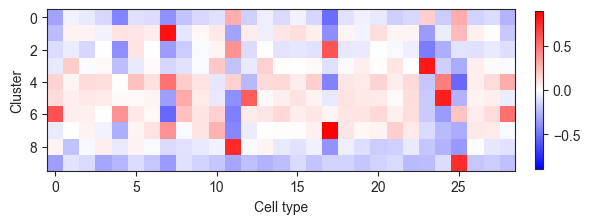

In [52]:
# Compute and visualize enrichment scores
enrichment = enrichment_score(
    cluster_mean_values = mean_values1,
    all_values = np.array(cell_type_frequencies)
)

task1d_plot_enrichment_scores(enrichment)

### Task 2: Radius-based neighborhood analysis (40 points)

An alternative approach to constructing neighborhoods is using a radius-based nearest-neighbor graph. Here, a cell is considered to be in the neighborhood of another cell if it is spatially closer than a predefined radius.

A. Run the analysis from Task 1 again with a radius $r$. Select $r$ by calculating the median distance of the 10th neighbor $\tilde{x}$ and the corresponding median absolute deviation (MAD). Choose $r = \tilde{x} + \text{MAD}$. (20 points)

B. Compare to the original result in terms of Spearman correlation between enrichment scores and adjusted rand index between clusters. Discuss the results. (10 points)

C. What are the advantages and disadvantages of both ways of constructing neighborhoods? (10 points)


In [12]:
def task2a_get_neighborhood_composition_radius(sample_data: pd.DataFrame, radius: float) -> pd.DataFrame:
    """
    Calculate the composition of each cell's neighborhood (defined through a radius)
    :param sample_data: A DataFrame of length n_cells_sample with columns X, Y, and Celltype
    :param radius: Float representing the size of the neighborhood
    :return: A DataFrame of shape (n_cells_sample, n_celltypes) containing neighborhood cell type frequencies.
    """
    cell_type_frequencies_sample_original = pd.DataFrame(index = sample_data.index, columns = CELLTYPES)

    knn = NearestNeighbors(
        radius = radius,
        n_jobs = 4,
        # Euclidean distance
        metric = "minkowski", p = 2
    )

    knn_fit = knn.fit(sample_data[["X", "Y"]])
    is_neighbor = knn_fit.kneighbors_graph(sample_data[["X", "Y"]])

    neighbors = np.array([list(is_neighbor[row].nonzero()[1]) for row in range(is_neighbor.shape[0])])

    cell_type_frequencies_sample = task1b_get_neighborhood_composition(
        sample_data = sample_data,
        neighbors = neighbors
    )

    assert cell_type_frequencies_sample_original.shape == cell_type_frequencies_sample.shape

    return cell_type_frequencies_sample

In [13]:
# Find a suitable value for the radius

# Perform knn with 10 neighbours
knn = NearestNeighbors(
    n_neighbors = 10,
    n_jobs = 4,
    # Euclidean distance
    metric = "minkowski", p = 2
)

knn_fit = knn.fit(data[["X", "Y"]])
is_neighbor = knn_fit.kneighbors_graph(data[["X", "Y"]], mode = "distance")

# Get the distances of the 10th neighbour (furthest)
distance_10th = np.array([
    is_neighbor[ is_neighbor[row].nonzero()[1] ].max() for row in range(is_neighbor.shape[0])
])

# Estimate radius
x_tilde = np.median(distance_10th)
mad = median_abs_deviation(distance_10th)

r = x_tilde + mad

print(f"Using radius: {round(r, 2)}")

In [14]:
# Compute cell neighborhoods for the samples and celltype frequencies
cell_type_frequencies2 = task2a_get_neighborhood_composition_radius(data, radius = r)

**Hint:** You can reuse the functions from Task 1C and Task 1D for the following part.

In [15]:
# Cluster cells based on their neighborhood compositions
clusters2, mean_values2 = task1c_clustering(cell_type_frequencies2, n_clusters = n_neighbors)

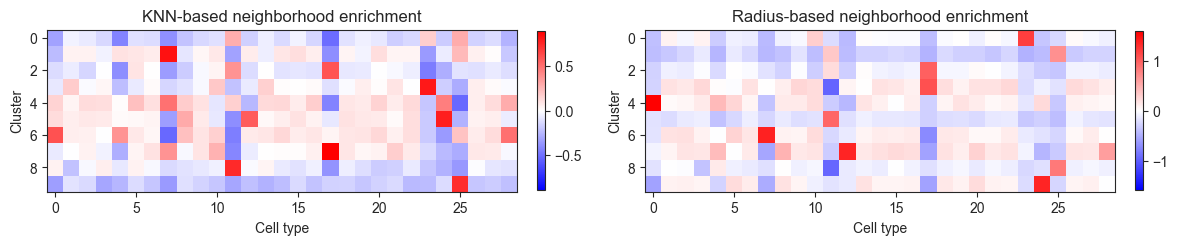

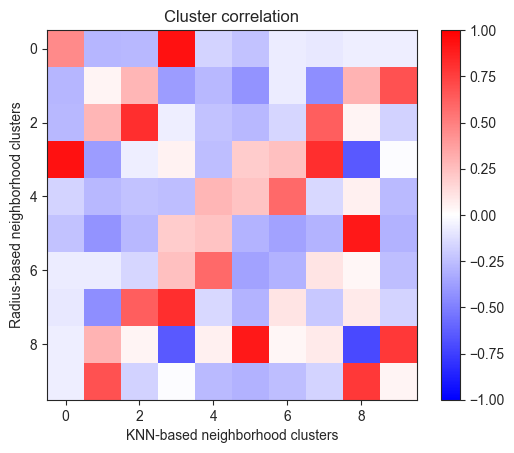

Adjusted Rand Index between the two clustering methods: 0.12


In [53]:
# Compare results

enrichment2 = enrichment_score(
    cluster_mean_values = mean_values2,
    all_values = np.array(cell_type_frequencies2)
)

plt.figure(figsize = (12, 6))

plt.subplot(1, 2, 1)
task1d_plot_enrichment_scores(enrichment)
plt.title("KNN-based neighborhood enrichment")

plt.subplot(1, 2, 2)
task1d_plot_enrichment_scores(enrichment2)
plt.title("Radius-based neighborhood enrichment")

plt.tight_layout()
plt.show()

corr = np.zeros((enrichment.shape[0], enrichment2.shape[0]))

for i, cluster1 in enumerate(enrichment):
    for j, cluster2 in enumerate(enrichment2):
        correlation = np.corrcoef(cluster1, cluster2)[0][1]
        corr[i][j] = correlation
        corr[j][i] = correlation

plt.imshow(corr, cmap = "bwr", vmin = -1, vmax = 1)
plt.xlabel("KNN-based neighborhood clusters")
plt.ylabel("Radius-based neighborhood clusters")
plt.title("Cluster correlation")
plt.colorbar()
plt.show()

ari_score = adjusted_rand_score(clusters1, clusters2)
print(f"Adjusted Rand Index between the two clustering methods: {round(ari_score, 2)}")

**Provide your text answers for Task 2B here**

**Provide your text answers for Task 2C here**

### Task 3

**Provide your text answers for Task 3A here**

In [ ]:
def task3b_compositional_transformation(cell_type_frequencies: pd.DataFrame) -> pd.DataFrame:
    """
    Transform cell type frequencies to account for their compositional nature
    :param cell_type_frequencies: A DataFrame of shape (n_cells, n_celltypes) containing neighborhood cell type frequencies.
    :return: A DataFrame of shape (n_cells, n_celltypes) containing transformed neighborhood cell type frequencies.
    """

In [ ]:
# Transform features to account for their compositional nature
#########################
# INSERT YOUR CODE HERE #
#########################

**Hint:** You can reuse the functions from Task 1C and Task 1D for the following part. Because of the transformation, you have to manually compute the cluster mean values here.

In [ ]:
# Cluster cells based on their neighborhood compositions
#########################
# INSERT YOUR CODE HERE #
#########################

**Provide your text answers for Task 3B here**